In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from ipywidgets import interact, IntSlider
import ipywidgets as widgets

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Generate synthetic data
X, _ = make_blobs(n_samples=1000, centers=10, cluster_std=0.60, random_state=0)

In [3]:
# Function to visualize the steps of K-Means
def plot_kmeans(k=3):
    kmeans = KMeans(n_clusters=k, random_state=0)
    y_kmeans = kmeans.fit_predict(X)

    plt.figure(figsize=(12, 8))
    
    # Plot the clusters
    plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', marker='o', alpha=0.5, label='Data Points')
    
    # Plot the centroids
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
    
    plt.title(f'K-Means Clustering with k={k}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Interactive slider for number of clusters
interact(plot_kmeans, k=IntSlider(min=1, max=20, step=1, value=5, description='Number of Clusters:'))

interactive(children=(IntSlider(value=5, description='Number of Clusters:', max=20, min=1), Output()), _dom_cl…

<function __main__.plot_kmeans(k=3)>

### K-Means Clustering

#### Overview
This demonstrates an interactive visualization of the K-Means clustering algorithm. K-Means is a popular clustering algorithm that partitions data into K distinct clusters based on feature similarities. The goal is to minimize the within-cluster sum of squares.

#### How It Works
- **Data Generation**: Synthetic data is generated using `make_blobs`, which creates isotropic Gaussian blobs for clustering. This data is ideal for demonstrating clustering as it has clear separation.
- **K-Means Clustering**:
  - The number of clusters (`k`) can be adjusted interactively.
  - For each `k`, the K-Means algorithm is applied to the data. The algorithm assigns each data point to the nearest cluster while keeping the centroids as small as possible.
  - The centroids of the clusters, which represent the mean of the points within each cluster, are recalculated iteratively until they stabilize.
- **Visualization**:
  - Data points are colored according to their cluster assignments.
  - Cluster centroids are marked distinctly to show their positions.
  - Users can interactively change the number of clusters to see how the clustering configuration changes.

#### Benefits of Visualization
- Provides intuitive understanding of how K-Means iteratively adjusts the clusters and centroids.
- Helps in determining the optimal number of clusters by visual inspection, which can be further analyzed using methods like the Elbow method.

## How to determine optimal clusters graphically

### 1. Elbow Method

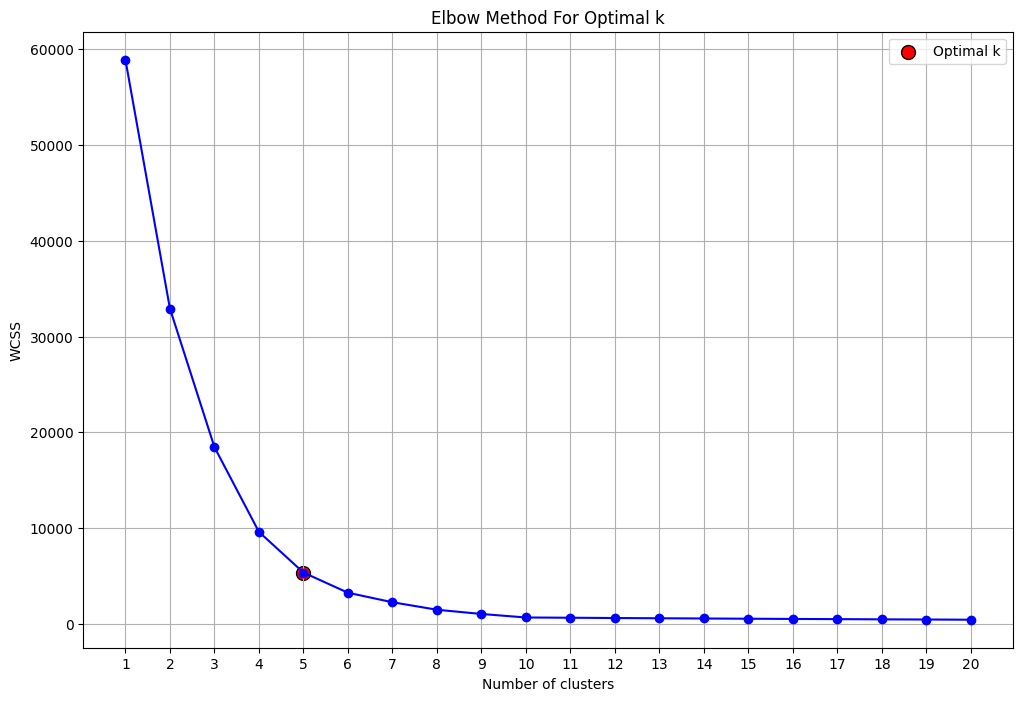

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def plot_elbow_method():
    wcss = []  # List to store the within-cluster sum of squares (WCSS)

    # Loop over a range of k values from 1 to 20
    for i in range(1, 21):
        # Initialize the KMeans object with the current number of clusters
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
        # Fit the model on the data
        kmeans.fit(X)
        # Append the inertia (WCSS) to the list
        wcss.append(kmeans.inertia_)

    # Calculate the point of maximum curvature in the WCSS curve
    x1, y1 = 1, wcss[0]  # First point
    x2, y2 = 20, wcss[-1]  # Last point

    distances = []
    # Calculate the distance of each point from the line joining the first and last point
    for i in range(len(wcss)):
        x0 = i + 1
        y0 = wcss[i]
        numerator = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
        denominator = np.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator / denominator)
    
    optimal_k = distances.index(max(distances)) + 1  # Find the index of the maximum distance

    plt.figure(figsize=(12, 8))  # Set the figure size
    plt.plot(range(1, 21), wcss, marker='o', linestyle='-', color='blue')  # Plot the WCSS values
    plt.title('Elbow Method For Optimal k')  # Set the title
    plt.xlabel('Number of clusters')  # Set the x-axis label
    plt.ylabel('WCSS')  # Set the y-axis label
    plt.xticks(np.arange(1, 21, step=1))  # Set the x-axis ticks
    plt.grid(True)  # Enable the grid

    # Highlight the optimal k value
    plt.scatter(optimal_k, wcss[optimal_k-1], color='red', s=100, edgecolor='k', label='Optimal k')
    plt.legend()  # Show the legend
    plt.show()  # Display the plot

plot_elbow_method()


## Elbow Method for K-Means Clustering

The Elbow method is used to determine the optimal number of clusters for k-means clustering. The method involves plotting the sum of squares within each cluster (WCSS) against the number of clusters and identifying the point where the curve makes a sharp turn (the elbow), suggesting a good balance between cluster compactness and the number of clusters.

### Function Definition

- `plot_elbow_method()`: This function calculates the WCSS for different numbers of clusters (from 1 to 20) and plots the results to visually determine the best value for k.

### WCSS Calculation

- **For Loop**: Iterates over a range of k values from 1 to 20.
  - `KMeans()`: Initializes a KMeans clustering with the specified number of clusters.
  - `fit(X)`: Fits the KMeans model to the dataset `X`.
  - `wcss.append(kmeans.inertia_)`: Appends the inertia (or WCSS) of the model to a list. Inertia is the sum of squared distances of samples to their nearest cluster center.

### Optimal k Calculation

- **Geometry for Elbow Detection**:
  - `x1, y1 = 1, wcss[0]`: Coordinates of the first point on the WCSS plot.
  - `x2, y2 = 20, wcss[-1]`: Coordinates of the last point on the WCSS plot.
  - Computes the perpendicular distance from each point on the curve to the line connecting `x1, y1` to `x2, y2`. The k value corresponding to the maximum distance is considered the optimal number of clusters.

### 2. Silhouette Score

For n_clusters = 2, the average silhouette score is: 0.5491648820412272
For n_clusters = 3, the average silhouette score is: 0.47203146574904686
For n_clusters = 4, the average silhouette score is: 0.570092156662047
For n_clusters = 5, the average silhouette score is: 0.590586621606481
For n_clusters = 6, the average silhouette score is: 0.6478918231301312
For n_clusters = 7, the average silhouette score is: 0.641517188305622
For n_clusters = 8, the average silhouette score is: 0.6848010427785223
For n_clusters = 9, the average silhouette score is: 0.7111029898134491
For n_clusters = 10, the average silhouette score is: 0.7261510187445367
For n_clusters = 11, the average silhouette score is: 0.690465943927795
For n_clusters = 12, the average silhouette score is: 0.6588225100473203
For n_clusters = 13, the average silhouette score is: 0.6036145954632917
For n_clusters = 14, the average silhouette score is: 0.5461857390833436
For n_clusters = 15, the average silhouette score is: 0.538145

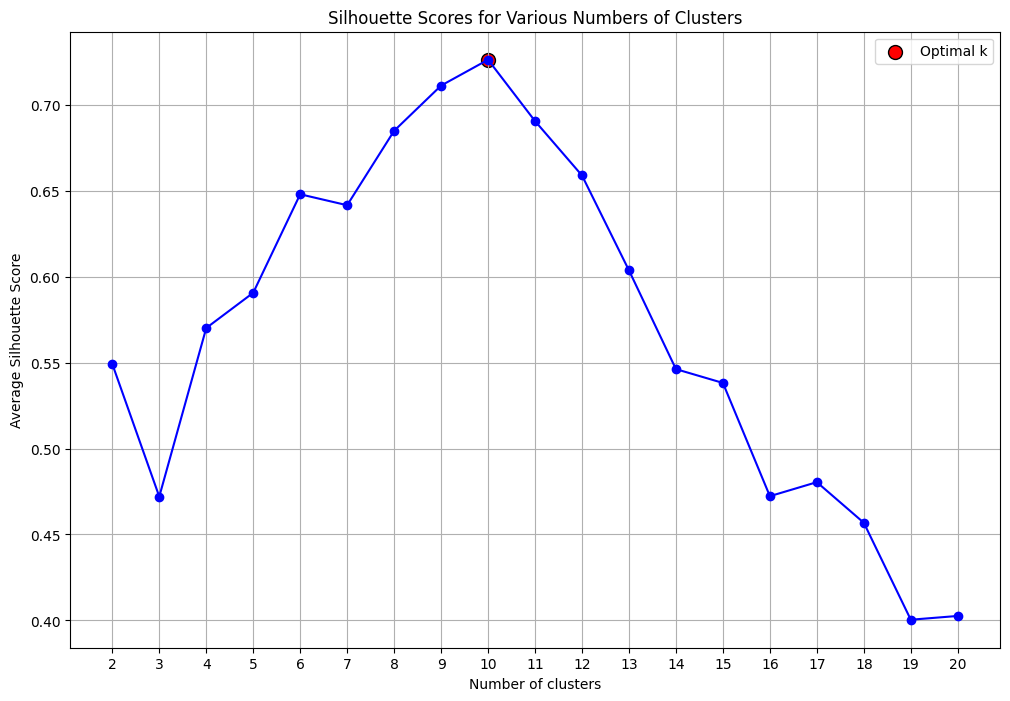

In [5]:
from sklearn.metrics import silhouette_score

# Function to calculate and plot Silhouette Scores for various cluster counts
def plot_silhouette_scores():
    silhouette_scores = []  # List to store the silhouette scores for each k
    range_n_clusters = list(range(2, 21))  # Silhouette score cannot be calculated for k=1

    # Loop through each number of clusters from 2 to 20
    for n_clusters in range_n_clusters:
        # Initialize KMeans clustering with the current number of clusters
        clusterer = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=0)
        # Perform clustering by fitting the model with the data X and predict the cluster index for each sample
        cluster_labels = clusterer.fit_predict(X)
        # Calculate the silhouette score for the current number of clusters and the given cluster labels
        silhouette_avg = silhouette_score(X, cluster_labels)
        silhouette_scores.append(silhouette_avg)  # Append the average silhouette score to the list
        print(f"For n_clusters = {n_clusters}, the average silhouette score is: {silhouette_avg}")

    # Determine the number of clusters that has the maximum silhouette score
    optimal_k = range_n_clusters[np.argmax(silhouette_scores)]

    # Plotting
    plt.figure(figsize=(12, 8))  # Set the size of the plot
    # Plot the silhouette scores for each number of clusters
    plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='-', color='blue')
    plt.title('Silhouette Scores for Various Numbers of Clusters')  # Set the title of the plot
    plt.xlabel('Number of clusters')  # Set the x-axis label
    plt.ylabel('Average Silhouette Score')  # Set the y-axis label
    plt.xticks(range_n_clusters)  # Set the ticks on the x-axis to the range of cluster numbers
    plt.grid(True)  # Enable the grid for better readability

    # Highlight the optimal number of clusters with the maximum silhouette score
    plt.scatter(optimal_k, silhouette_scores[optimal_k-2], color='red', s=100, edgecolor='k', label='Optimal k')
    plt.legend()  # Add a legend to identify the marked point
    plt.show()  # Display the plot

# Call the function to execute the above steps
plot_silhouette_scores()


## Silhouette Score for Optimal Cluster Number Determination

The Silhouette Score is used to evaluate the quality of clusters created by a clustering algorithm. It measures how similar each data point is to its own cluster compared to other clusters. A high Silhouette Score indicates that clusters are dense and well-separated.

### Function Definition

- `plot_silhouette_scores()`: This function computes the Silhouette Scores for a range of cluster numbers and plots these scores to help identify the optimal number of clusters for K-means clustering.

### Silhouette Score Calculation

- **Range of Clusters**: Defines the range of potential cluster counts from 2 to 20. Silhouette Score is not defined for a single cluster because it requires more than one cluster to compute inter-cluster distances.

- **Loop Over Cluster Counts**:
  - `KMeans()`: Initializes a KMeans object with a specified number of clusters, using 'k-means++' for initialization to speed up convergence, and sets the maximum iterations and the number of initialization attempts.
  - `fit_predict()`: Fits the KMeans model to the data and predicts the cluster labels for each data point.
  - `silhouette_score()`: Calculates the average Silhouette Score for the current number of clusters, assessing how well the data points have been grouped into clusters.

### Optimal k Calculation

- **Find Optimal k**: Determines the number of clusters that maximizes the Silhouette Score, which indicates the best balance between maximum cluster density and separation.


This method is particularly useful when the optimal clustering configuration is not known a priori, as it provides a quantitative measure to support the choice of the number of clusters in k-means clustering.

## Interactive visualization of K-Means with optimal clusters 

In [6]:
# Initialize centroids randomly
np.random.seed(42)
k = 10
centroids = X[np.random.choice(X.shape[0], k, replace=False)]

def kmeans(X, centroids, k, max_iters=50):
    history = []

    for _ in range(max_iters):
        # Calculate distances and assign clusters
        distances = np.linalg.norm(X - centroids[:, np.newaxis], axis=2)
        labels = np.argmin(distances, axis=0)

        # Store history for animation
        history.append((centroids.copy(), labels.copy()))

        # Recompute centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    
    return history

# Run K-means and get history of centroids and labels
history = kmeans(X, centroids, k)


# Setup the figure and axes
fig = go.Figure(
    data=[go.Scatter(x=X[:, 0], y=X[:, 1], mode='markers', marker=dict(color='grey', size=7)),
          go.Scatter(x=centroids[:, 0], y=centroids[:, 1], mode='markers', marker=dict(color='red', size=12, symbol='x'))],
    layout=go.Layout(
        xaxis=dict(range=[X[:, 0].min()-1, X[:, 0].max()+1], autorange=False),
        yaxis=dict(range=[X[:, 1].min()-1, X[:, 1].max()+1], autorange=False),
        title="K-Means Clustering Visualization",
        width = 1200,
        height = 800,
        updatemenus=[dict(type="buttons",
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, {"frame": {"duration": 500, "redraw": True},
                                                     "fromcurrent": True}]),
                                   dict(label="Pause",
                                        method="animate",
                                        args=[[None], {"frame": {"duration": 0, "redraw": False},
                                                       "mode": "immediate",
                                                       "transition": {"duration": 0}}])])],
        sliders=[{
            'steps': [{'method': 'animate', 'args': [[f'name{i}'],
                                                    {'mode': 'immediate',
                                                     'frame': {'duration': 500, 'redraw': True},
                                                     'transition': {'duration': 0}}], 'label': str(i)}
                      for i in range(len(history))]
        }]
    ),
    frames=[go.Frame(
        data=[go.Scatter(
            x=X[:, 0],
            y=X[:, 1],
            mode='markers',
            marker=dict(color=hist[1], size=7, colorscale='Viridis', line=dict(color='black', width=1)),
            ),
            go.Scatter(
                x=hist[0][:, 0],
                y=hist[0][:, 1],
                mode='markers',
                marker=dict(color='red', size=12, symbol='x')
            )
        ],
        name=f'name{i}'
    ) for i, hist in enumerate(history)]
)

# Show the plot
fig.show()

## Interactive K-Means Clustering Visualization

### Initialization
- **Centroids**: Initialize `k` centroids randomly chosen from the dataset.
- **Seed**: Set a random seed for reproducibility.

### K-means Function
- **Function Definition**: A function `kmeans` that performs K-means clustering, which is specified to run for a maximum of `max_iters` iterations or until centroids no longer change.

- **Distance Calculation**: Calculate the Euclidean distance from each data point to each centroid.
- **Cluster Assignment**: Assign each data point to the nearest centroid.
- **Centroid Update**: Calculate new centroids by finding the mean of the points in each cluster.
- **History Tracking**: Keep a history of centroids and labels for each iteration to use in the animation.

### Plotly Visualization
- **Figure Setup**: Initialize a Plotly figure with scatter plots for data points and centroids.
- **Animation**: Each frame of the animation represents an iteration of the K-means algorithm, showing updated cluster assignments and centroids.
- **Controls**: Include play and pause buttons to control the animation, and a slider to jump to different iterations.

### Execution
- **Run K-means**: Call the `kmeans` function and pass the data along with initial centroids.
- **Show Plot**: Display the interactive plot with controls.

